In [4]:
import torch.nn.functional as F
import torch
import random
import matplotlib.pyplot as plt

In [3]:
words = open('names.txt', 'r').read().splitlines()
len(words)

32033

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [37]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

# 拆分训练集
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
Xtr,Ytr = build_dataset(words[:n1]) # 80%
Xdev,Ydev = build_dataset(words[n1:n2]) # 10%
Xte,Yte = build_dataset(words[n2:]) #10%

In [38]:
#MLP revisit
n_emb = 10 # the number of dimentionality of the character embadding vectors
n_hidden = 200 # the number of nurons in the hidden layer of the MLP

# int parameter
# hide layer
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(27,n_emb,               generator=g)
hide_input = block_size * n_emb
W1 = torch.randn(hide_input, n_hidden,  generator=g)
b1 = torch.randn(n_hidden,              generator=g)
# softmax
W2 = torch.randn(n_hidden, 27,          generator=g) # 27 outputs
b2 = torch.randn(27,                    generator=g)

parameters = [W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # num of parameters in total
for p in parameters:
    p.requires_grad = True

11627


In [39]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minbactch
    ix = torch.randint(0, Xtr.shape[0], (batch_size, )) # random select 32 inputs
    Xb, Yb = Xtr[ix], Ytr[ix]
    

    # forward pass
    emb = C[Xb] # embeded characters in to vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden-layer pre-activiation
    h = torch.tanh(hpreact) # hiden-layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    #backward
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += - lr * p.grad

    # track state

    if (i % 10000 == 0):
        print(f'{i:7d} / {max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0 / 200000: 25.9601
  10000 / 200000: 2.3634
  20000 / 200000: 3.2365
  30000 / 200000: 2.0707
  40000 / 200000: 1.9975
  50000 / 200000: 2.0379
  60000 / 200000: 2.4652
  70000 / 200000: 1.8746
  80000 / 200000: 2.0372
  90000 / 200000: 1.6561
 100000 / 200000: 1.9823
 110000 / 200000: 2.2865
 120000 / 200000: 2.0020
 130000 / 200000: 1.8488
 140000 / 200000: 1.7132
 150000 / 200000: 2.1918
 160000 / 200000: 1.6975
 170000 / 200000: 2.1097
 180000 / 200000: 1.8843
 190000 / 200000: 1.7899


initial loss is too heigh, and drop too fast. 

期望的 loss，27 个 character 等概率出现 `loss = -torch.tensor(1/27).log()`

用正态分布获取的随机参数会取到较极端的值，导致了高loss

In [43]:
-torch.tensor(1/27).log()

tensor(3.2958)

In [ ]:
# 4-dimensional example of the issue
logits = torch.tensor([0, 0, 0, 0]).float()
# logits = torch.randn(4) * 10 randn 会输出过于偏离的初始值
probs = torch.softmax(logits, dim= 0)
loss = -probs[2].log() # 将第二个视为label
logits, probs, loss.item()

(tensor([  0.6720,  -3.8511, -12.6961,  -3.7129]),
 tensor([9.7721e-01, 1.0608e-02, 1.5285e-06, 1.2179e-02]),
 13.39122200012207)

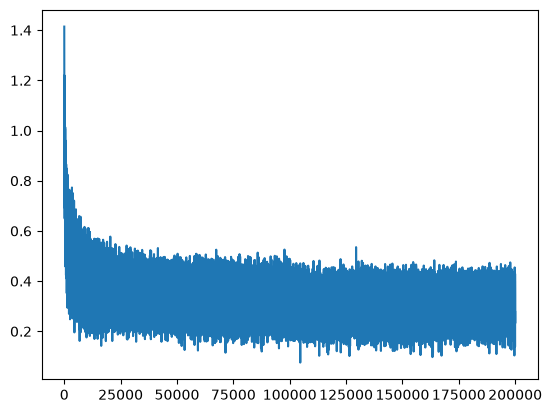

In [40]:
plt.plot(lossi)

In [41]:
@torch.no_grad() # decorator -- disable gradian tracking
def split_loss(split):
    x, y = {
        'train': {Xtr, Ytr},
        'val': {Xdev, Ydev},
        'test': {Xte, Yte}
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f'{split}, {loss.item()}')
    
split_loss('train')
split_loss('test')

train, 2.041525363922119
test, 2.4523937702178955


In [42]:
# sample from the model
# g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

cori.
arshikora.
sha.
eline.
ivery.
jorabel.
arya.
caton.
hadijah.
anabid.
luri.
brecu.
syan.
salyilya.
kiya.
pyttisyn.
manyah.
har.
aramsityann.
glis.


In [29]:
block_size

3